In [16]:
import torch
import torch.nn.functional as F
import matplotlib.pylab as plt
%matplotlib inline

In [17]:
words = open("names.txt", 'r').read().splitlines()


In [18]:
#build the vocabulary of characters and mapping to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s: i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i : s for s, i in stoi.items()}
vocab_size = len(itos)
vocab_size

27

In [19]:
block_size = 3 #context length: how many characters do we take to predict the next one

def build_dataset(words):
    xs, ys = [], []

    for w in words:
        context = [0] * block_size #0 in period char
        for ch in w + '.':
            ix = stoi[ch]
            xs.append(context)
            ys.append(ix)

            context = context[1:] + [ix] #crop and append
    
    xs = torch.tensor(xs)
    ys = torch.tensor(ys)
    print(xs.shape, ys.shape)

    return xs, ys


import random
random.seed(42)
random.shuffle(words)

n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1]) # 80%
Xdev, Ydev = build_dataset(words[n1:n2]) # 10%
Xte, Yte = build_dataset(words[n2:]) # 10%


torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [62]:
# MLP revisted
n_embd = 10 # the dimensionality of the character enbedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5 / 3) / ((n_embd * block_size) ** 0.5)
b1 = torch.randn(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0

bngain = torch.ones((1, n_hidden)) #batch normailization
bnbais = torch.zeros((1, n_hidden))

bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbais]

print(sum(p.nelement() for p in parameters)) #number of parameters in total

for p in parameters:
    p.requires_grad = True

12297


In [ ]:
#you don't need to use, b in previous in case you are using batch narmalization bias, now it takes charge of bias

In [63]:
#same optimization as the last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    #minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    #forward pass
    emb = C[Xb] #embed the chararcters into vectors
    embcat = emb.view(emb.shape[0], -1) #concate the vectors
    hpreact = embcat @ W1 + b1 # hidden layer pre activation
    #gaussian batch normalization , Z value
    bnmeani = hpreact.mean(dim=0, keepdim=True)
    bnstdi = hpreact.std(dim=0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbais #batch normalization

    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi


    h = torch.tanh(hpreact) #hidden layer
    logits = h @ W2 + b2  #output layer
    loss = F.cross_entropy(logits, Yb) #loss function

    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    #update
    lr = 0.1 if i < 100000 else 0.01 #step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    #track stats
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d} : {loss.item(): .4f}')
    lossi.append(loss.log10().item())

    #break;



      0/ 200000 :  3.3147
  10000/ 200000 :  2.1984
  20000/ 200000 :  2.3375
  30000/ 200000 :  2.4359
  40000/ 200000 :  2.0119
  50000/ 200000 :  2.2595
  60000/ 200000 :  2.4775
  70000/ 200000 :  2.1020
  80000/ 200000 :  2.2788
  90000/ 200000 :  2.1862
 100000/ 200000 :  1.9474
 110000/ 200000 :  2.3010
 120000/ 200000 :  1.9837
 130000/ 200000 :  2.4523
 140000/ 200000 :  2.3839
 150000/ 200000 :  2.1987
 160000/ 200000 :  1.9733
 170000/ 200000 :  1.8668
 180000/ 200000 :  1.9973
 190000/ 200000 :  1.8347


In [44]:
hpreact.mean(dim=0, keepdim=True).shape
hpreact.std(dim=0, keepdim=True).shape

torch.Size([1, 200])

In [ ]:
#With batch normalization we don't much focus on initail values of parameters as batch normallization takes cares of that
# it automatically provides regulaization and based upon different batches, we do see entropy

(array([  6.,  17.,  20.,  30.,  49.,  61.,  72.,  89.,  87.,  99., 135.,
        121., 153., 134., 138., 140., 174., 163., 179., 184., 138., 196.,
        183., 226., 165., 212., 191., 175., 201., 211., 189., 186., 166.,
        178., 183., 156., 194., 155., 171., 140., 139., 122., 102.,  96.,
         81.,  72.,  41.,  39.,  23.,  18.]),
 array([-0.95476669, -0.91695139, -0.87913609, -0.84132079, -0.80350549,
        -0.76569018, -0.72787488, -0.69005958, -0.65224428, -0.61442898,
        -0.57661368, -0.53879838, -0.50098307, -0.46316777, -0.42535247,
        -0.38753717, -0.34972187, -0.31190657, -0.27409127, -0.23627596,
        -0.19846066, -0.16064536, -0.12283006, -0.08501476, -0.04719946,
        -0.00938416,  0.02843115,  0.06624645,  0.10406175,  0.14187705,
         0.17969235,  0.21750765,  0.25532295,  0.29313826,  0.33095356,
         0.36876886,  0.40658416,  0.44439946,  0.48221476,  0.52003006,
         0.55784537,  0.59566067,  0.63347597,  0.67129127,  0.70910657,
 

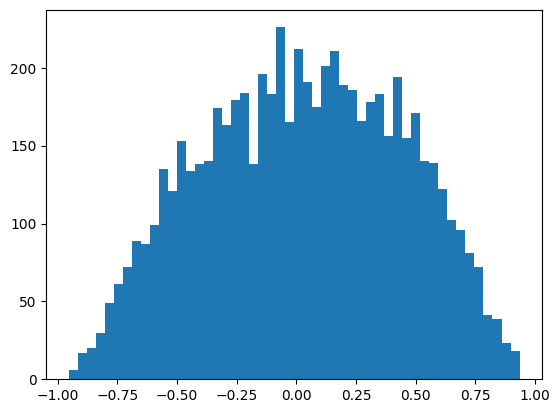

In [33]:
plt.hist(h.view(-1).tolist(), 50)

(array([  1.,   2.,   0.,   1.,   5.,   3.,  10.,   7.,  12.,  12.,  24.,
         39.,  40.,  76.,  66.,  98., 127., 171., 191., 207., 227., 275.,
        310., 288., 360., 368., 384., 352., 363., 338., 304., 281., 287.,
        229., 207., 166., 137., 101.,  90.,  74.,  46.,  28.,  28.,  21.,
         11.,   8.,  11.,   5.,   2.,   7.]),
 array([-1.88309634, -1.81133971, -1.73958308, -1.66782645, -1.59606983,
        -1.5243132 , -1.45255657, -1.38079994, -1.30904332, -1.23728669,
        -1.16553006, -1.09377343, -1.02201681, -0.95026018, -0.87850355,
        -0.80674692, -0.7349903 , -0.66323367, -0.59147704, -0.51972041,
        -0.44796379, -0.37620716, -0.30445053, -0.2326939 , -0.16093728,
        -0.08918065, -0.01742402,  0.05433261,  0.12608923,  0.19784586,
         0.26960249,  0.34135912,  0.41311574,  0.48487237,  0.556629  ,
         0.62838563,  0.70014225,  0.77189888,  0.84365551,  0.91541214,
         0.98716877,  1.05892539,  1.13068202,  1.20243865,  1.27419528,
 

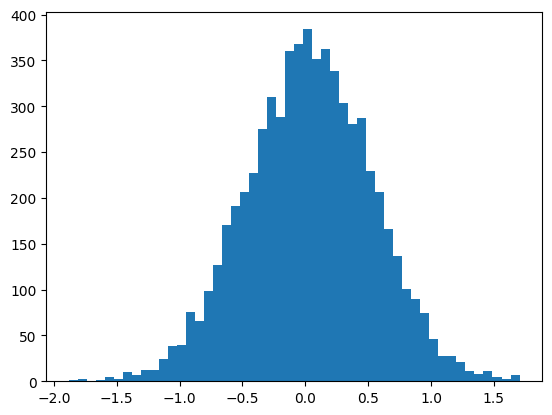

In [34]:
plt.hist(hpreact.view(-1).tolist(), 50)

In [ ]:
#hpreeact have values are tha very saturated, we wanted to close to zero

In [ ]:
#if you observe , that if tanh value are close to 1 or -1 that its derivative would very close to 0, 
# hence there is very minimal effect of tanh gradient through that path
# even tanh close to 1 then tanh layer is just like a passthrough layer, tan backpass is a gradient decreasing function


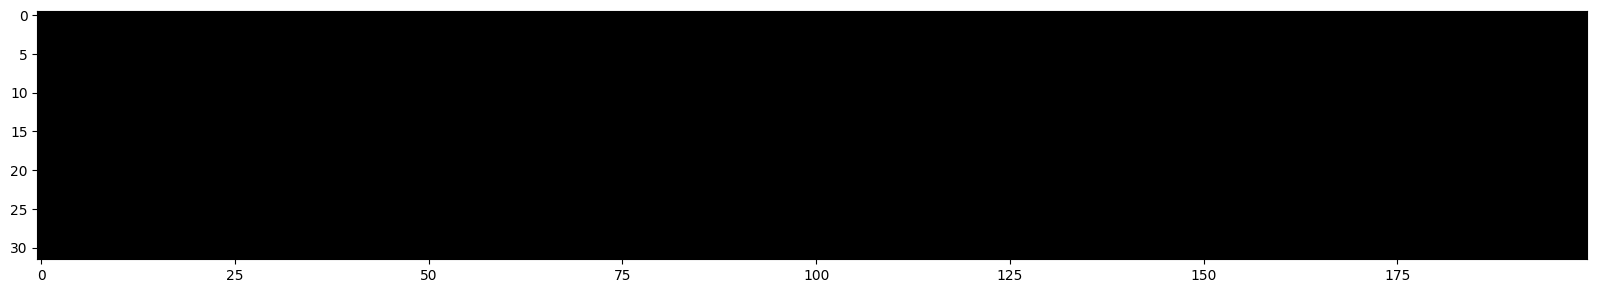

In [35]:
plt.figure(figsize=(20, 20))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

In [ ]:
#we can see there are very large values with white , however there is no neuron is dead, means amount 32 neurons , 
# there no only white row 

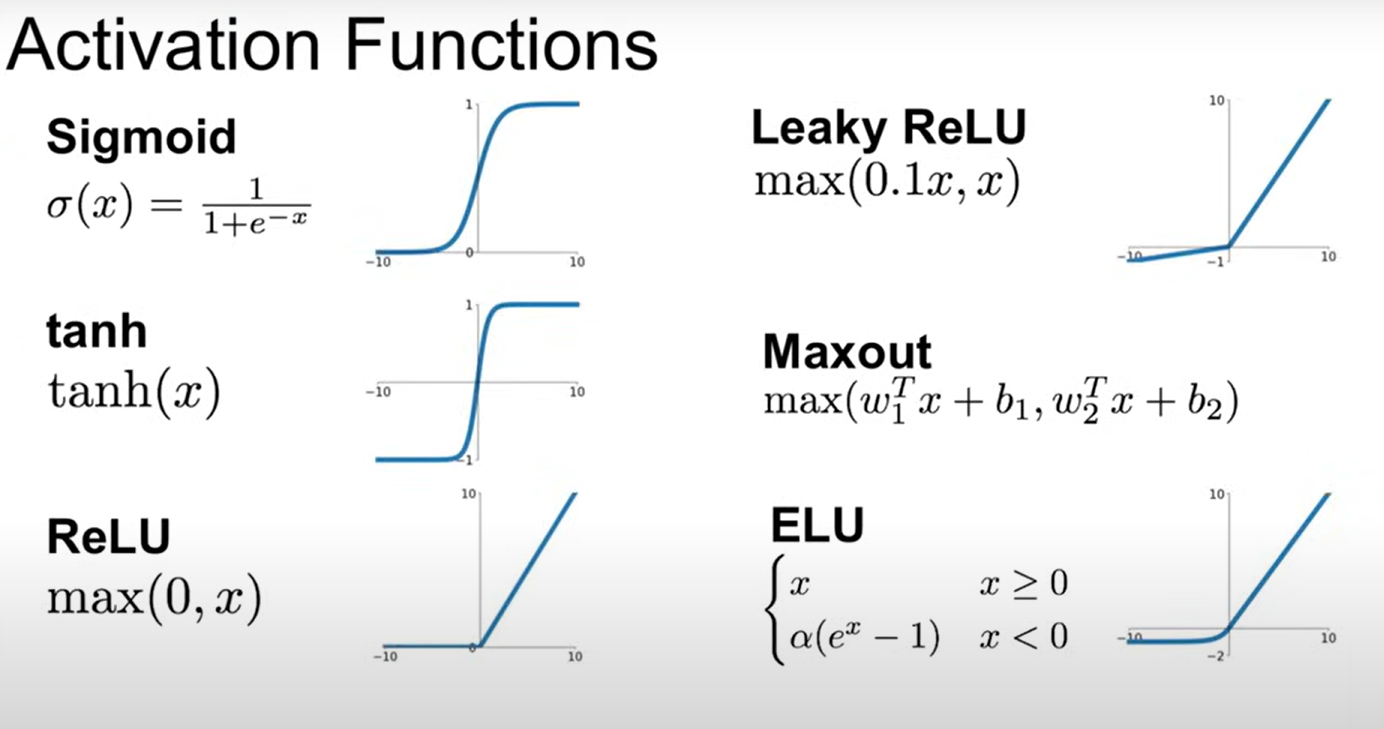


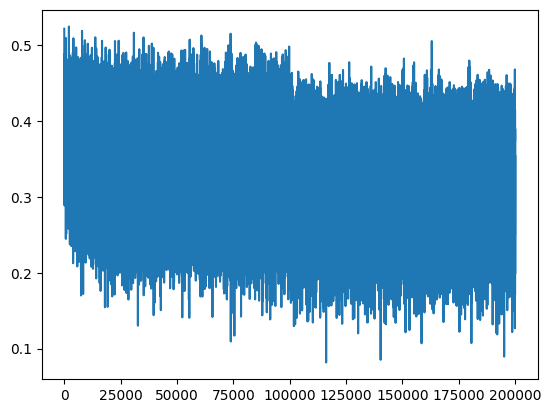

In [22]:
plt.plot(lossi)

In [57]:
#anothet tricky challenge that we face with batch normalization during test time, how do we feed in individaul input,
# BN operates on batch, solution to this is as below

with torch.no_grad():
    # pass the traing set through
    emb = C[Xtr]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    # measure the mean/std over the entire training set

    bnmean = hpreact.mean(0, keepdim=True)
    bnstd = hpreact.std(0, keepdim=True)
    
     

In [67]:
#bnmean and bnmean_running, bnstd and bnstd would be roughly same
bnstd_running

tensor([[2.3689, 2.0998, 2.2499, 1.9599, 2.1515, 2.3429, 2.2431, 2.3104, 2.3309,
         2.0823, 2.4680, 2.2253, 2.1192, 2.1805, 2.0655, 2.6865, 2.4191, 1.8718,
         2.1882, 2.4989, 2.2903, 2.3143, 2.1068, 1.9938, 2.0172, 1.8189, 2.1352,
         2.5721, 2.2250, 2.3027, 1.6857, 1.8987, 2.0912, 1.8024, 2.0771, 1.9073,
         2.4760, 2.1356, 2.0873, 1.8440, 1.9877, 2.0603, 2.3704, 1.9412, 1.9464,
         2.4033, 2.1706, 2.5046, 2.1319, 2.4826, 2.0177, 1.8196, 1.9937, 1.7548,
         2.3758, 2.1857, 1.7500, 2.2775, 2.5494, 1.7520, 2.0970, 1.9272, 2.0154,
         2.2870, 2.1270, 2.3166, 2.1311, 2.4586, 2.0074, 2.1552, 2.0607, 1.9617,
         1.9790, 2.2357, 1.8885, 1.8480, 2.5581, 2.1731, 1.6619, 2.2316, 1.9924,
         1.8106, 1.9824, 2.1808, 2.4859, 2.3152, 2.1121, 2.3617, 2.5755, 2.6760,
         2.0648, 1.9299, 2.1034, 1.9445, 1.8592, 2.1894, 2.1640, 2.0496, 1.8632,
         2.3143, 2.0495, 2.1165, 2.2337, 1.9762, 1.9748, 2.2615, 1.8477, 2.1645,
         1.9084, 2.1207, 2.3

In [58]:
@torch.no_grad() #this decorator disables gradient tracking

def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte)
    }[split]

    emb = C[x] #(N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) #cancat into (N, block_size *embd)
    hpreact = embcat @ W1 + b1 # (N, n_hidden)
    #hpreact = bngain * (hpreact - hpreact.mean(dim=0, keepdim=True)) / hpreact.std(dim=0, keepdim=True) + bnbais #batch normalization
    hpreact = bngain * (hpreact - bnmean) / bnstd + bnbais #batch normalization
    h = torch.tanh(hpreact) #(n_hidden, vocab_size)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y) #loss function
    print(split, loss.item())

split_loss('train')
split_loss('val')
    



train 2.0667526721954346
val 2.1048367023468018


In [ ]:
#sample from model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size #initialize with all ...
    while True:
        #forward pass the neural net
        emb = C[torch.tensor([context])] # (1, block_size, n_embd)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        # shift the context window and track the samples
        context = context[1:] + [ix]
        out.append(ix)
        #if we sample the special '.' token break
        if ix == 0:
            break

    print(''.join(itos[i] for i in out)) #decode and print the generated word


carpahzarbriq.
shlimrixtts.
lusslaysierricnenddhn.
frtivgqliyah.
farrichaiirdnsleggyu.
bmanvitte.
sants.
lustvi.
vabbuwatth.
giidryxiidh.
sulipsables.
falia.
gtas.
jasfaylahas.
bduricsydustquovozswy.
bjumillassannyks.
sadlusoffordst.
sramsryndlycpllmanraq.
shelseombriyabhda.
ffxrdustvebndvi.


In [ ]:
#At initilaization the loss shoun't be that big (27), each outcome need to have uniform distribution
#1/27, below is expected initial loss
-torch.tensor(1.0/27).log()
#initial logits should be much closer to 0
#so assiging
#b2 = 0
#W3 *= 0.01
# if initial loss if high we are going to few of iterations to squash the wieghts then optimize them
# if you plot hidden value at the initial step you would see most of the values are -1 or 1

tensor(3.2958)

tensor(0.0045) tensor(1.0006)
tensor(-0.0026) tensor(0.9889)


(array([1.61055019e-04, 1.40923142e-04, 2.81846283e-04, 3.62373793e-04,
        7.24747585e-04, 1.24817640e-03, 2.45608904e-03, 4.83165057e-03,
        7.48905838e-03, 1.31863797e-02, 2.12793944e-02, 3.23519269e-02,
        5.39936951e-02, 8.32654448e-02, 1.26166476e-01, 1.77180653e-01,
        2.45166003e-01, 3.12929902e-01, 3.78741009e-01, 4.22568106e-01,
        4.31224813e-01, 4.11092936e-01, 3.55186713e-01, 2.86315560e-01,
        2.12773812e-01, 1.56706533e-01, 1.03981147e-01, 6.94348451e-02,
        4.56389660e-02, 2.73189576e-02, 1.75348652e-02, 9.66330114e-03,
        6.50259639e-03, 3.52307854e-03, 2.01318774e-03, 1.20791264e-03,
        6.84483831e-04, 4.22769425e-04, 3.01978161e-04, 1.20791264e-04,
        1.20791264e-04, 4.02637547e-05, 2.01318774e-05, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 2.01318774e-05]),
 array([-5.04363728, -4.79527494, -4.54691261, -4.29855028, -4.05018795,
        -3.80182562, 

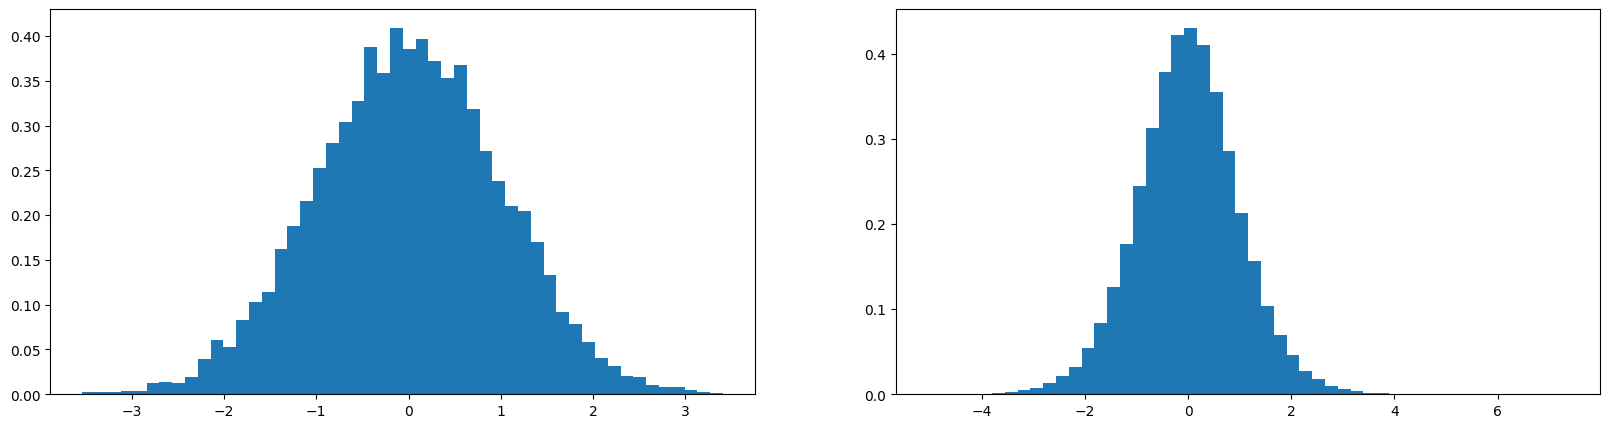

In [ ]:
#how do we can get these right set of initial weights values, they are important in 50-layer nn
x = torch.randn(1000, 10)
w = torch.randn(10, 200) / 10 ** 0.5
y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())

plt.figure(figsize=(20, 5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density=True)

plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density=True)


In [ ]:
#one way to have unification on intialization is divide the parameters via sqrt(fanin)
#[10, 100] , fanin 100 
#Kaiming_normal
torch.randn(10000).std()
# tanh 
(5 / 3) / ((n_embd * block_size) ** 0.5)

0.3042903097250923